<a href="https://colab.research.google.com/github/addieby06/AI_Project/blob/main/Copy_of_data_science_milestone_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The Effect of Song Length on Song Popularity Throughout Time**
---


**Addie Ben-Yoseph and Ben Frankstein**

[Link to our GitHub Pages site](https://benfrankstein.github.io/)

## **Project Motivation**

Song durations have changed noticeably over the past 70 years, with songs growing longer through the album era of the 70s and 80s, then beginning to shrink again in the streaming era of the 2000s. We want to understand whether this shift is tied to what makes a song popular, and whether shorter songs actually chart better today than they did in previous decades.

In terms of data science, this tutorial is important because it involves analyzing trends over time, relationships between variables like duration and popularity, and evaluating the signficance, or lackthereof, of these patterns, helping to inform us on the broader music industry as a whole.

## **Research Question**

How does the duration of a song relate to its popularity, and has that
relationship changed over time?

## **Datasets**

To answer this, we combine two datasets:

1. **30,000 Spotify Songs** (Kaggle) — gives us per-song duration, genre,
   and a Spotify popularity score (0-100). Good for audio features, but the
   popularity score is biased toward recent streams, so it's not reliable as
   a historical measure of how popular a song *was* when released.

2. **Billboard Hot 100** (1958-present, via the utdata/rwd-billboard-data
   GitHub archive) — gives us weekly chart positions for every song that
   has ever charted. This gives us a *time-accurate* measure of popularity
   (peak chart position, weeks on chart) that the Spotify score can't.

Joining these on (artist, track) lets us ask the duration question using
both a modern streaming-era signal (Spotify popularity) and a historically
consistent signal (Billboard chart performance).

## **Further Resources**
[Why Songs Seem Shorter—And Why It’s More Complicated Than You Think
](https://hmc.chartmetric.com/shorter-songs-trend-streaming-history/)

[How Has Music Changed Since the 1950s? A Statistical Analysis](https://www.statsignificant.com/p/how-has-music-changed-since-the-1950s-62a)

***Collaboration Plan:***  
We are planning to meet on Zoom or in-person 2 times a week in order to complete this project. In addition, we are setting up a page on Github where we can work on code and troubleshoot as well as using a shared doc where we can keep track of any ideas and additional information we plan to share in the final tutorial.

# **Extraction, Transformation, and Loading (ETL)**

## Dataset 1: 30,000 Spotify Songs

We loaded a single .csv file from this [Kaggle Dataset](https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs) containing over 30,000 Spotify songs. The original dataset includes 23 columns of track metadata and audio features from the Spotify API — such as danceability, energy, tempo, valence, and more. We trimmed the data down to 6 key columns: track_name, track_artist, track_popularity, playlist_genre, duration_ms, and track_album_release_date. We then converted duration_ms to a new duration_sec column and extracted release_year from the album release date, dropping the original duration_ms and track_album_release_date columns afterward. Any rows with missing release years, track names, or artists were removed, and release_year was cast to an integer. Any exact rows were also dropped. The final tidied dataset has a shape of (28,622 × 6) with zero missing values.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')
spotify = pd.read_csv('/content/drive/My Drive/spotify_songs.csv')

#spotify = pd.read_csv('/content/spotify_songs.csv')

# preview shape of data and columns
print("Spotify Shape:", spotify.shape)
spotify.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Spotify Shape: (32833, 23)


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [ ]:
# keep the columns that matter for our analysis
spotify = spotify[['track_name', 'track_artist', 'track_popularity',
                    'track_album_release_date', 'playlist_genre', 'duration_ms']]
spotify['duration_sec'] = spotify['duration_ms'] / 1000 #make the time human readable in seconds

#transform date to datetime and extract the year
spotify['track_album_release_date'] = pd.to_datetime(spotify['track_album_release_date'], errors='coerce')
spotify['release_year'] = spotify['track_album_release_date'].dt.year

#drop the columns that we transformed into more readable
spotify = spotify.drop(columns=['duration_ms', 'track_album_release_date'])

#dropping rows where the release year or track name/artist is missing
spotify = spotify.dropna(subset=['release_year', 'track_name', 'track_artist'])
spotify = spotify.drop_duplicates() #drop duplicate rows with all the columns being exactly the same

#make the year an integer
spotify['release_year'] = spotify['release_year'].astype(int)

#drop
print("Missing values per column:")
print(spotify.isnull().sum())
print()
print("Data types:")
print(spotify.dtypes)
print(spotify.shape)

Missing values per column:
track_name          0
track_artist        0
track_popularity    0
playlist_genre      0
duration_sec        0
release_year        0
dtype: int64

Data types:
track_name           object
track_artist         object
track_popularity      int64
playlist_genre       object
duration_sec        float64
release_year          int64
dtype: object
(28622, 6)


In [ ]:
spotify.head()

,track_name,track_artist,track_popularity,playlist_genre,duration_sec,release_year
0,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,pop,194.754,2019
1,Memories - Dillon Francis Remix,Maroon 5,67,pop,162.600,2019
2,All the Time - Don Diablo Remix,Zara Larsson,70,pop,176.616,2019
3,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,pop,169.093,2019
4,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,pop,189.052,2019


## Tidy Data

Following the principles of tidy data, we ensure that:
- Each variable forms its own column
- Each observation (song) forms its own row  
- Each cell contains a single value

## Dataset 2: Billboard Hot 100 (1958-present)

To complement the Spotify data, we bring in the **Billboard Hot 100** chart
archive. Billboard's Hot 100 has ranked the 100 most popular songs in the
US every week since August 1958, and unlike Spotify's popularity score it
reflects how popular a song actually was *at the time it was released*.

**Source:** We use the `hot-100-current.csv` archive maintained by
[utdata/rwd-billboard-data](https://github.com/utdata/rwd-billboard-data),
which stitches together the original Kaggle archive, data.world fills, and
ongoing weekly scrapes. It is updated weekly and matches what is currently
live on billboard.com.

**Shape of the raw data:** Each row is one (song, performer, chart_week)
triple — so a song that stayed on the chart for 20 weeks appears 20 times.
We will need to aggregate this up to one row per song before joining it
with Spotify.

**Significant Columns:**
- `chart_week` — date of the weekly chart
- `song` — song title
- `performer` — artist(s)
- `current_week` — chart position that week (1-100)
- `peak_position` — best position reached so far
- `wks_on_chart` — cumulative weeks on chart so far

In [ ]:
# Download the Billboard Hot 100 archive from the utdata GitHub repo.

import urllib.request
import os

BILLBOARD_URL = (
    "https://raw.githubusercontent.com/utdata/rwd-billboard-data/"
    "main/data-out/hot-100-current.csv"
)
BILLBOARD_PATH = "hot100.csv"

# Only download if we don't already have it cached locally
if not os.path.exists(BILLBOARD_PATH):
    urllib.request.urlretrieve(BILLBOARD_URL, BILLBOARD_PATH)
    print(f"Downloaded to {BILLBOARD_PATH}")
else:
    print(f"Using cached copy at {BILLBOARD_PATH}")

print(f"File size: {os.path.getsize(BILLBOARD_PATH) / 1e6:.1f} MB")

Downloaded to hot100.csv
File size: 19.5 MB


In [ ]:
# Load the raw Billboard CSV into billboard_raw variable and look at the columns and datatypes
import pandas as pd

billboard_raw = pd.read_csv(BILLBOARD_PATH)

print("Raw Billboard shape:", billboard_raw.shape)
print("\nColumns:", list(billboard_raw.columns))
print("\nDtypes:")
print(billboard_raw.dtypes)
billboard_raw.head()

Raw Billboard shape: (353500, 7)

Columns: ['chart_week', 'current_week', 'title', 'performer', 'last_week', 'peak_pos', 'wks_on_chart']

Dtypes:
chart_week       object
current_week      int64
title            object
performer        object
last_week       float64
peak_pos          int64
wks_on_chart      int64
dtype: object


,chart_week,current_week,title,performer,last_week,peak_pos,wks_on_chart
0,2022-01-01,1,All I Want For Christmas Is You,Mariah Carey,1.0,1,50
1,2022-01-01,2,Rockin' Around The Christmas Tree,Brenda Lee,2.0,2,44
2,2022-01-01,3,Jingle Bell Rock,Bobby Helms,4.0,3,41
3,2022-01-01,4,A Holly Jolly Christmas,Burl Ives,5.0,4,25
4,2022-01-01,5,Easy On Me,Adele,3.0,1,11


### Tidy transformations

Before we can join to Spotify we need to:

1. **Keep columns we want to use**
2. **Parse `chart_week` as a datetime** and extract the year.
3. **Drop rows that have missing songs or performers**
4. **Aggregate to one row per song** — collapse the weekly rows down to a
   single row per `(song, performer)` with:
   - `peak_position` — the best (lowest-numbered) position the song ever
     hit. This is our primary ground-truth popularity signal.
   - `weeks_on_chart` — how many distinct weeks it appeared. A secondary
     popularity signal capturing longevity.
   - `year_first_charted` — the year the song debuted on the Hot 100. This
     is what we'll treat as its "release era" for historical comparisons.

In [ ]:
# Normalize our column names
rename_map = {
    "title":    "song",
    "peak_pos": "peak_position",
    "chart_date":     "chart_week",
    "chart_position": "current_week",
    "time_on_chart":  "wks_on_chart",
}
billboard_raw = billboard_raw.rename(columns=rename_map)
print("Standardized columns:", billboard_raw.columns.tolist())

# columns that we will use for our second database
needed = ["chart_week", "song", "performer", "current_week",
          "peak_position", "wks_on_chart"]
missing = [c for c in needed if c not in billboard_raw.columns]
if missing:
    raise KeyError(f"Expected Billboard columns missing: {missing}. "
                   f"Got: {billboard_raw.columns.tolist()}")

billboard = billboard_raw[needed].copy()

# prase chart week to be datetime so we can extract the year
billboard["chart_week"] = pd.to_datetime(billboard["chart_week"], errors="coerce")

# drop rows where songs and performers are
before = len(billboard)
billboard = billboard.dropna(subset=["song", "performer", "chart_week"])

# print data to see the new shapes, types and names all together
print("\nCleaned weekly Billboard shape:", billboard.shape)
print("\nDate range:", billboard["chart_week"].min().date(),
      "to", billboard["chart_week"].max().date())
print("\nDtypes:")
print(billboard.dtypes)
billboard.head()

Standardized columns: ['chart_week', 'current_week', 'song', 'performer', 'last_week', 'peak_position', 'wks_on_chart']

Cleaned weekly Billboard shape: (353500, 6)

Date range: 1958-08-04 to 2026-05-02

Dtypes:
chart_week       datetime64[ns]
song                     object
performer                object
current_week              int64
peak_position             int64
wks_on_chart              int64
dtype: object


,chart_week,song,performer,current_week,peak_position,wks_on_chart
0,2022-01-01,All I Want For Christmas Is You,Mariah Carey,1,1,50
1,2022-01-01,Rockin' Around The Christmas Tree,Brenda Lee,2,2,44
2,2022-01-01,Jingle Bell Rock,Bobby Helms,3,3,41
3,2022-01-01,A Holly Jolly Christmas,Burl Ives,4,4,25
4,2022-01-01,Easy On Me,Adele,5,1,11


In [ ]:
# collpase the weekly rows into groups if the same song has been present on the charts for more than 1 week to reduce data bloat
billboard_songs = (
    billboard
    .groupby(["song", "performer"], as_index=False)
    .agg(
        peak_position=("peak_position", "min"),
        weeks_on_chart=("chart_week", "nunique"),
        year_first_charted=("chart_week", lambda s: s.min().year),
    )
)

# make sure datatypes are properly casted to use for analysis later
billboard_songs["peak_position"] = billboard_songs["peak_position"].astype(int)
billboard_songs["weeks_on_chart"] = billboard_songs["weeks_on_chart"].astype(int)
billboard_songs["year_first_charted"] = billboard_songs["year_first_charted"].astype(int)

print("One-row-per-song Billboard shape:", billboard_songs.shape)
print("\nDtypes:")
print(billboard_songs.dtypes)
print("\nMissing values per column:")
print(billboard_songs.isnull().sum())
billboard_songs.head()

One-row-per-song Billboard shape: (32529, 5)

Dtypes:
song                  object
performer             object
peak_position          int64
weeks_on_chart         int64
year_first_charted     int64
dtype: object

Missing values per column:
song                  0
performer             0
peak_position         0
weeks_on_chart        0
year_first_charted    0
dtype: int64


,song,performer,peak_position,weeks_on_chart,year_first_charted
0,"""B"" Girls",Young And Restless,54,15,1990
1,"""Cherry Cherry"" from Hot August Night",Neil Diamond,31,10,1973
2,"""Having A Party"" Medley",The Ovations (Featuring Louis Williams),56,9,1973
3,"""Joy"" Pt. I",Isaac Hayes,30,9,1973
4,"""Roots"" Medley",Quincy Jones,57,7,1977


## Merging Spotify and Billboard

Now we join the two cleaned datasets on `(artist, track)`. The same song can appear as
`"Umbrella"` in one source and `"Umbrella (feat. JAY-Z)"` in the other,. A direct string join on raw names will miss
most matches.

To handle this we build a **normalized join key** on both sides:

- lowercase everything
- strip featured-artist tags like `(feat. X)`, `- Remix`, `- Remastered`
- remove punctuation and collapse whitespace
- for the artist field, keep only the primary/first artist

This won't catch every match (misspellings, translated titles, etc.) but
it gets us a solid intersection. We use an **inner join** so the merged
dataset contains only songs that appear in *both* sources — these are the
songs for which we have both audio/duration features AND historical chart
performance.

In [ ]:
import re

#normalize the titles so its easier to do comparisons
def normalize_title(s: str) -> str:
    s = str(s).lower()
    # remove parenthesized or bracketed additions: (these are common in song titles)
    s = re.sub(r"[\(\[].*?[\)\]]", "", s)
    # strip " - Remix", " - Remastered 2011", " - Radio Edit", etc.
    s = re.sub(r"\s*-\s*(remix|remaster(ed)?|radio edit|single version|album version|live|acoustic|mono|stereo).*$", "", s)
    # remove punctuation
    s = re.sub(r"[^\w\s]", "", s)
    # collapse whitespace
    s = re.sub(r"\s+", " ", s).strip()
    return s
#normalize the title to keep only the main artist and not all the featuring artists
def normalize_artist(s: str) -> str:
    s = str(s).lower()
    # cut at "featuring", "feat.", "ft.", "with", "x", "&", ","
    s = re.split(r"\s+(?:featuring|feat\.?|ft\.?|with|x|&|,)\s+", s)[0]
    s = re.sub(r"[^\w\s]", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

# identify the join keys on spotify dataset
spotify["_track_key"]  = spotify["track_name"].apply(normalize_title)
spotify["_artist_key"] = spotify["track_artist"].apply(normalize_artist)

#identify the join keys on the billboard dataset
billboard_songs["_track_key"]  = billboard_songs["song"].apply(normalize_title)
billboard_songs["_artist_key"] = billboard_songs["performer"].apply(normalize_artist)

# Inner join — keep only songs found in both datasets.
merged = spotify.merge(
    billboard_songs,
    on=["_track_key", "_artist_key"],
    how="inner",
)

# if a song has duplicates keep the row with the highest spotify popularity. this is to reduce the duplicate comparisons that we will make
# we made the assumption that other duplicates are remixes or covers which aren't as popular as the orignal most of the time
merged = (
    merged
    .sort_values("track_popularity", ascending=False)
    .drop_duplicates(subset=["_track_key", "_artist_key"], keep="first")
    .reset_index(drop=True)
)

# Drop the join-key columns
merged = merged.drop(columns=["_track_key", "_artist_key"])

print("Spotify rows:            ", len(spotify))
print("Billboard songs rows:    ", len(billboard_songs))
print("Merged (inner-join) rows:", len(merged))
print("\nDtypes:")
print(merged.dtypes)
print("\nMissing values per column:")
print(merged.isnull().sum())
merged.head()

Spotify rows:             28622
Billboard songs rows:     32529
Merged (inner-join) rows: 3147

Dtypes:
track_name             object
track_artist           object
track_popularity        int64
playlist_genre         object
duration_sec          float64
release_year            int64
song                   object
performer              object
peak_position           int64
weeks_on_chart          int64
year_first_charted      int64
dtype: object

Missing values per column:
track_name            0
track_artist          0
track_popularity      0
playlist_genre        0
duration_sec          0
release_year          0
song                  0
performer             0
peak_position         0
weeks_on_chart        0
year_first_charted    0
dtype: int64


,track_name,track_artist,track_popularity,playlist_genre,duration_sec,release_year,song,performer,peak_position,weeks_on_chart,year_first_charted
0,Dance Monkey,Tones and I,100,pop,209.438,2019,Dance Monkey,Tones And I,4,36,2019
1,ROXANNE,Arizona Zervas,99,edm,163.636,2019,Roxanne,Arizona Zervas,4,26,2019
2,Tusa,KAROL G,98,pop,200.960,2019,Tusa,Karol G & Nicki Minaj,42,21,2019
3,The Box,Roddy Ricch,98,edm,196.653,2019,The Box,Roddy Ricch,1,38,2019
4,Circles,Post Malone,98,r&b,215.280,2019,Circles,Post Malone,1,61,2019


### Tidy data check — merged dataset

Our merged DataFrame satisfies three tidy-data rules:

- **Each variable is its own column** — `track_name`, `track_artist`,
  `track_popularity`, `playlist_genre`, `duration_sec`, `release_year`,
  `peak_position`, `weeks_on_chart`, `year_first_charted` are each one
  variable.
- **Each observation is its own row** — one row = one song that appears in
  both Spotify and Billboard.
- **Each cell is a single value** — no lists, no embedded multi-values.

Dtypes are set appropriately (numeric where numeric, string where string,
int for years and chart positions). No missing values remain in the
columns we'll use for modeling.

This merged dataset is what the EDA and modeling sections below will work
from. We kept the two source datasets (`spotify` and `billboard_songs`)
around separately too, in case we want to do any analysis that requires
the full non-intersected populations.

# **Exploratory Data Analysis (EDA)**


Now that our data is clean, we explore some initial statistics to better understand
the relationship between song duration, release year, and popularity.

### What the initial statistics tell us:

1. **There was an average duration of 223.9 seconds or ~3.7 min.** This give us a base line into the standard duration of a song through all genres.

2. **Duration by decade:** We saw that songs grew longer from the 1950s through the 1980s peaking at around 270 seconds but then starting to decline through the 2020s reaching about 196 seconds.

3. **Correlation of -0.14:** There was a slight negative correlation between duration and popularity. Shorter songs tend to be more popular. This would be intresting to explore further.

4. **Popularity by genre:** Pop and Latin lead in popularity while EDM trails.

5. **Duration by genre:** Rock songs average ~247 seconds while Rap averages
   ~212 seconds. The difference in length per genre could show to be important in our further analysis of what influences the popularity of a song the most.

The bar chart above clearly shows the rise and fall of song length over the decades. In particular, as the data moves into more recent years, we find that the average duration of songs have become much shorter than those released in the past. These statistics prove significant as we look to analyze how the length of a song correlates to its popularity, and how that has impacted how long artists are making their songs now compared to in the past. Additionally, this chart and timeline reflect how this trend may also be related to and influenced by the ever-growing factors of technology and social media platforms like Tik Tok affecting the attention spans of listeners, and how this in turn might impact the length of songs that artists feel will gain the most popularity upon release.

## **Exploratory Data Analysis (EDA) - Merged Datasets**

In [ ]:
# --- Stat 1: Correlation between duration and Billboard peak position by decade ---
# Add decade column to merged dataset (we created it earlier on spotify only)
merged['decade'] = (merged['release_year'] // 10) * 10

print("Correlation between duration and Billboard peak position by decade:")
print("(Note: peak_position is 1-100 where LOWER = more popular,")
print(" so a positive correlation means longer songs peak worse)\n")
for decade in sorted(merged['decade'].unique()):
    decade_data = merged[merged['decade'] == decade]
    if len(decade_data) < 5:  # skip decades with too few charted songs
        continue
    corr = decade_data['duration_sec'].corr(decade_data['peak_position'])
    print(f"{decade}s (n={len(decade_data)}): {corr:.4f}")

Correlation between duration and Billboard peak position by decade:
(Note: peak_position is 1-100 where LOWER = more popular,
 so a positive correlation means longer songs peak worse)

1960s (n=38): -0.0065
1970s (n=179): 0.0623
1980s (n=331): -0.0358
1990s (n=491): 0.0913
2000s (n=737): -0.0413
2010s (n=1351): -0.0458
2020s (n=20): -0.1164


In [ ]:
# --- Stat 2: Cross-tabulation between duration based on decade and genre ---
import pandas as pd
cross_tab = pd.crosstab(
    index=merged['decade'],
    columns=merged['playlist_genre'],
    values=merged['peak_position'],
    aggfunc='mean'
).round(1)
print("\nAverage Billboard Peak Position by Decade and Genre:")
print("(Lower numbers = better chart performance)")
print(cross_tab)


Average Billboard Peak Position by Decade and Genre:
(Lower numbers = better chart performance)
playlist_genre   edm  latin   pop   r&b   rap  rock
decade                                             
1960             NaN    1.0  14.0  15.7   NaN  20.2
1970             NaN    2.0  11.0  18.9  28.0  21.1
1980            33.0   23.6  16.4  14.3  36.4  17.3
1990             NaN   26.4  24.9  19.4  41.7  25.9
2000            38.7   31.4  19.1  25.0  30.2  32.9
2010            26.7   36.7  28.3  40.9  43.9  34.9
2020            38.7    2.0   NaN  42.0  55.3  75.0


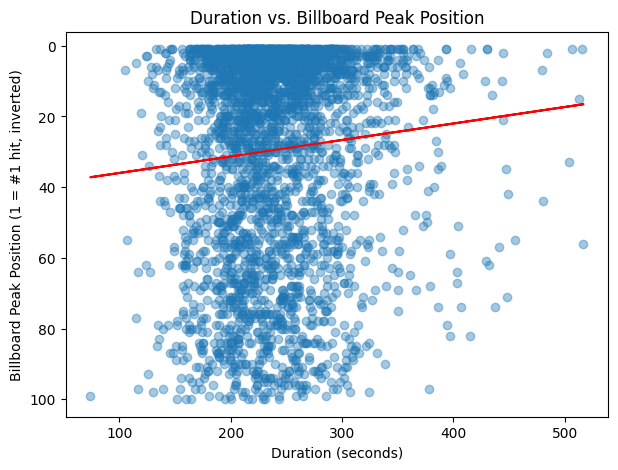

In [ ]:
# --- Stat 3: Scatterplot of duration vs Billboard peak position ---
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7,5))

plt.scatter(
    # x-axis: song duration in seconds
    merged['duration_sec'],
    # y-axis: best chart position (1 = #1 hit, 100 = barely charted)
    merged['peak_position'],
    alpha=0.4
)

# fit a linear trend line
z = np.polyfit(merged['duration_sec'], merged['peak_position'], 1)
p = np.poly1d(z)
plt.plot(merged['duration_sec'], p(merged['duration_sec']), color='red')

# invert y-axis so "more popular" appears at the top of the plot
plt.gca().invert_yaxis()

# set axis titles
plt.title('Duration vs. Billboard Peak Position')
plt.xlabel('Duration (seconds)')
plt.ylabel('Billboard Peak Position (1 = #1 hit, inverted)')

plt.show()

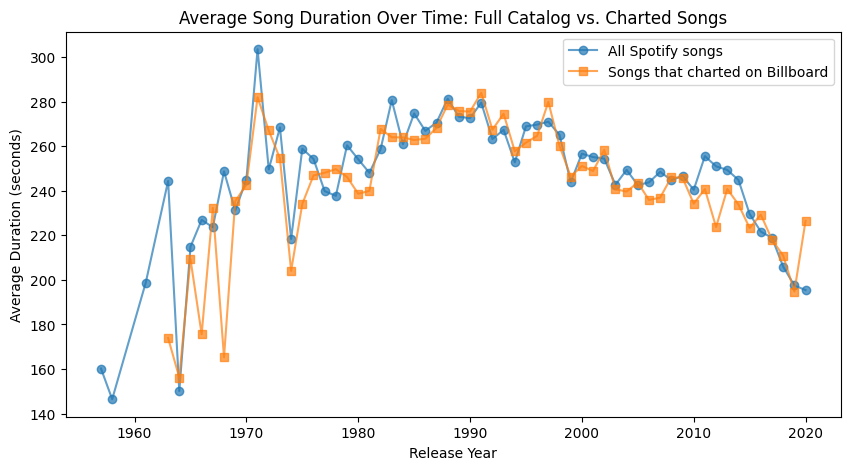

In [ ]:
# --- Stat 4: Average duration over time — Spotify catalog vs charted songs ---

spotify_yearly = spotify.groupby('release_year')['duration_sec'].mean()
merged_yearly = merged.groupby('release_year')['duration_sec'].mean()

plt.figure(figsize=(10, 5))
plt.plot(spotify_yearly.index, spotify_yearly.values,
         marker='o', label='All Spotify songs', alpha=0.7)
plt.plot(merged_yearly.index, merged_yearly.values,
         marker='s', label='Songs that charted on Billboard', alpha=0.7)

plt.title('Average Song Duration Over Time: Full Catalog vs. Charted Songs')
plt.xlabel('Release Year')
plt.ylabel('Average Duration (seconds)')
plt.legend()
plt.show()

### What the further merged-dataset analysis tells us:

In the Spotify EDA in which we used track_popularity, it reflected current streaming activity which meant that older songs looked unpopular even if they were big in their respective eras. We added the top 100 billboards dataset to get a better look at how popular the track was in its respective era. Now for the merged EDA, we are using a more historically accurate dataset.

1. The duration-popularity correlation didn't hold up with Billboard data. When we switched the metric that isn't biased on recent streams the correlation was between -.12 and +.09 (essentially 0). This suggests that the pattern in the Spotify database was biased towards a newer Spotify popularity metric and it just so happened that the high popularity songs were shorter. We found that amongst the songs that actually made the Top 100 billboards, the length didn't predict how high they peaked.
2. An analysis on how genre and decade peak position showed interesting metrics. Latin and Pop were dominating the top positions in the 60s and 70s and Rock peaking in the 80s. Other genres didn't have big enough sample sizes to make a clear distinction from it.
3. Our duration-peak scatter plot showed us that there wasn't a visible trend. There were songs of all different lengths at all positions. We wanted to see if there was a clear duration that meant a higher peak position but that wasn't visible. This gave us a good insight into helping us answer our research question.
4. Lastly we looked at how the songs on the Top 100 billboard list held up compared to all music catalogs. From the 1970s to 2010s they followed roughly the same trend. But after the 2020s the charted songs were actually longer than the catalog average. This actually was helpful to see as it pushes against the "shorter attention span" of the recent generation because then we would expect songs that are more popular to be shorter.

After doing a deeper analysis of the merged dataset, we see that the duration trend over time where after the 2000s it starts to decline is true. But the initial hypothesis that duration affected popularity doesn't hold up when we implement historically accurate "popularity" data (based on the rankings of the billboards). Going even further, we would look into the how and why the music industry is making shorter songs rather than are the shorter songs making them more popular.

# **Model Questions**

Based on our EDA above it helped us figure out two distinct models to help answer our questions. In this section we will identify the independent and dependent variables, methodology, and what each model would tell us.

### **Model 1:**

**Question:** How do we characterize the trend in song duration over time?

**Independent Variables:** 'release_year'.  
**Dependent Variable:** 'duration_sec'.

**Methodology:** We use a piecewise linear regression model with a knot at the year 2000. Then, we compute the yearly average durations and fit a least-squares line through years before 2000 and after 2000s. We then can compare the magnitude of the two slopes to see if there is a difference and how drastic the change is between the two time periods.   


### **Model 2:**

**Question:** Does song duration acutally predict Billboard chart success during each era?

**Independent variables:** duration_sec, release_year, and an interaction term between the two.   
**Dependent variable:** peak_position (1-100, where lower = more popular).

**Methodology:** Multiple linear regression on the merged dataset: peak_position ~ duration_sec + post_2000 + duration_sec * post_2000



This would help us test if the duration effect changes between the album era (pre 2000) and streaming era (post 2000). Though we know that there isn't a distinctive overall correlation, we wanted to dive deeper and see if a pooled regression can help us find a effect within eras.




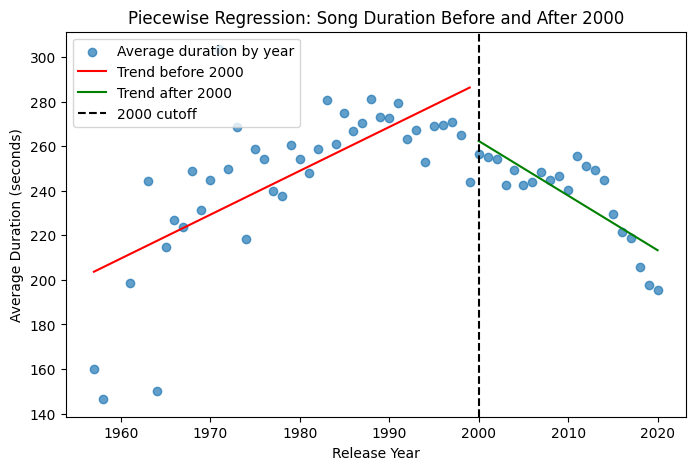

Before 2000 slope: 1.9667066386012444
After 2000 slope: -2.4504932969692512


In [ ]:
#@title Model 1 - Piecewise regression model

# Piecewise regression model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# group by release year and calculate average song duration
yearly_duration = spotify.groupby('release_year')['duration_sec'].mean().reset_index()

# create cutoff year
cutoff = 2000

# create variable for years before/after cutoff
yearly_duration['years_since_cutoff'] = yearly_duration['release_year'] - cutoff

# create piecewise variable
# before 2000 = 0
# after 2000 = years since 2000
yearly_duration['after_2000'] = np.where(
    yearly_duration['release_year'] >= cutoff,
    yearly_duration['release_year'] - cutoff,
    0
)

# fit regression model
coefficients = np.polyfit(
    yearly_duration['release_year'],
    yearly_duration['duration_sec'],
    1
)

# fit separate trend line before 2000
before_2000 = yearly_duration[yearly_duration['release_year'] < cutoff]
before_line = np.polyfit(
    before_2000['release_year'],
    before_2000['duration_sec'],
    1
)

# fit separate trend line after 2000
after_2000 = yearly_duration[yearly_duration['release_year'] >= cutoff]
after_line = np.polyfit(
    after_2000['release_year'],
    after_2000['duration_sec'],
    1
)

# create plot
plt.figure(figsize=(8,5))

# plot actual yearly averages
plt.scatter(
    yearly_duration['release_year'],
    yearly_duration['duration_sec'],
    alpha=0.7,
    label='Average duration by year'
)

# plot before-2000 regression line
plt.plot(
    before_2000['release_year'],
    np.poly1d(before_line)(before_2000['release_year']),
    color='red',
    label='Trend before 2000'
)

# plot after-2000 regression line
plt.plot(
    after_2000['release_year'],
    np.poly1d(after_line)(after_2000['release_year']),
    color='green',
    label='Trend after 2000'
)

# add vertical cutoff line
plt.axvline(
    x=cutoff,
    color='black',
    linestyle='--',
    label='2000 cutoff'
)

# labels and title
plt.title('Piecewise Regression: Song Duration Before and After 2000')
plt.xlabel('Release Year')
plt.ylabel('Average Duration (seconds)')
plt.legend()

plt.show()

# print slopes
print("Before 2000 slope:", before_line[0])
print("After 2000 slope:", after_line[0])

# **Model 1 Insight**

Overall, this model illustrates the trend of duration increase across the decades, eventually leading to a drastic decrease in the last 1990s and 2000s. This model also shows that the decrease in duration is occuring at a faster rate than the previous increase in durations, demonstrating how quickly the music industry is changing over time to keep up with changes listener consumption and behaviors in the modern era.

# **Model 1 Conclusion**

At first we wanted to see how duration affects the popularity of a song and if that relationship has changed over time given that it's true. We used two datasets. A catalog of 30,000 Spotify songs over time and the Billboard Hot 100 database to gather more historically accurate popularity of certain songs.

**Findings:**

We found that song duration overall had changed dramatically. Pre-2000's the average duration of songs increased by 2 seconds per year and then post-2000 shrank by an average of 2.5 seconds per year. From this we could tell that the music industry was shedding song length faster than it gained in the past.

We then found that shorter songs don't actually mean that the song would be more popular. After using Billboard peak position which is historically more accurate than Spotify's popularity metric, there was no real correlation between the song lengths and its charted success across all the decades. Initially, with just the Spotify popularity metric, there was a negative correlation but it was small enough to say it was a coincidence rather than a link.

After looking into the data to answer our questions a bigger story arose. Since song duration doesn't affect popularity of songs the recent decrease in song length has to be because of other drivers. Going forward we would analyze different potential drivers for the song length. Potentially, the supply side (artists and labels) and if there are correlations between the song length and more specifically those that are producing it. We could potentially find economic drivers, music algorithm preference and a shorter attention span demographic.

Overall, the duration was a trend and actually visible but the popularity was a mere coincidence and didn't have an actual correlation to the duration.



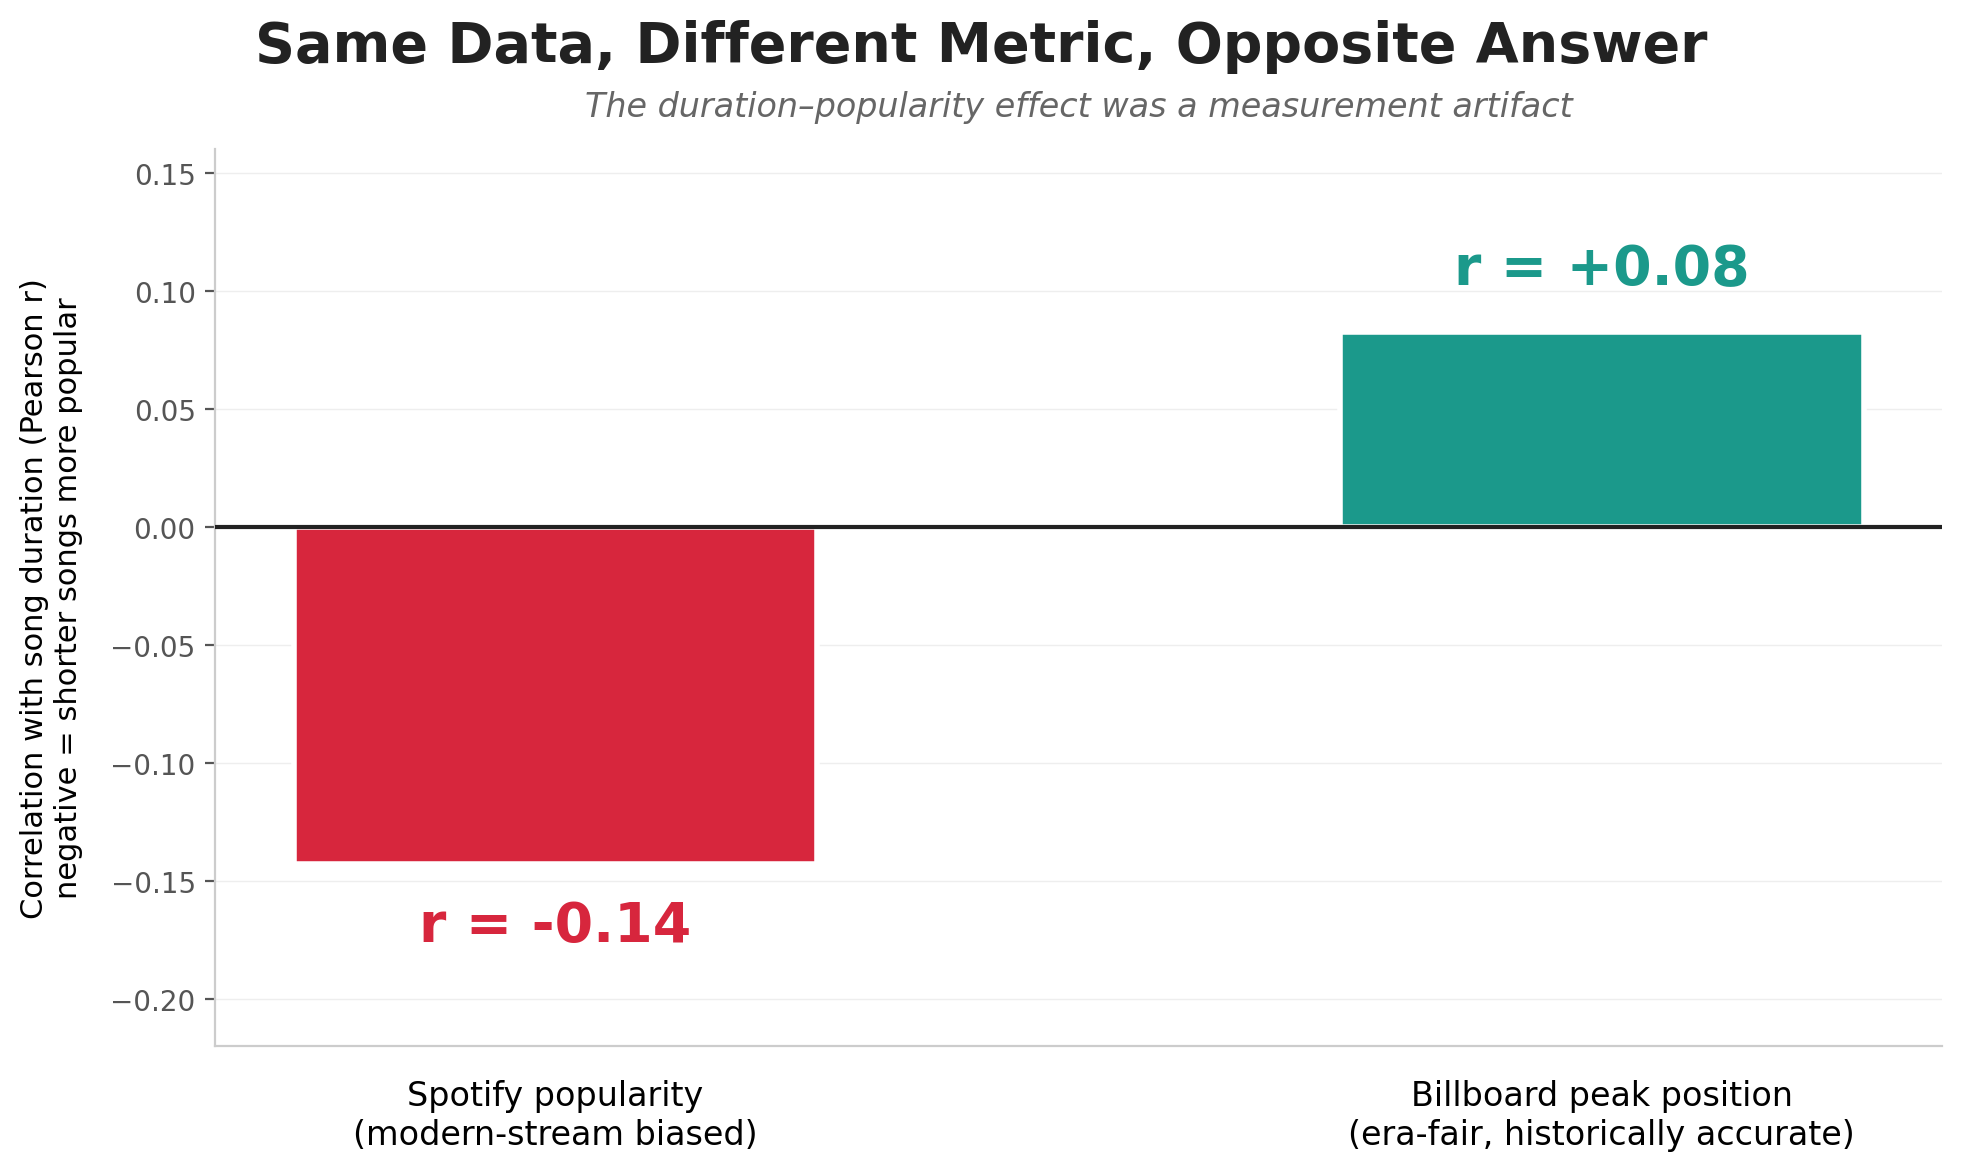

In [ ]:
#@title Model 2 visual: two popularity metrics, presentation version

import matplotlib.pyplot as plt

# --- compute correlations ---
spotify_corr = spotify['duration_sec'].corr(spotify['track_popularity'])
billboard_corr = -merged['duration_sec'].corr(merged['peak_position'])

# --- styling ---
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13})

fig, ax = plt.subplots(figsize=(10, 6.5), dpi=200)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# --- bars ---
labels = ['Spotify popularity\n(modern-stream biased)',
          'Billboard peak position\n(era-fair, historically accurate)']
values = [spotify_corr, billboard_corr]
colors = ['#D7263D', '#1B998B']

bars = ax.bar(labels, values, color=colors, width=0.5,
              edgecolor='white', linewidth=2, zorder=3)

# --- zero baseline ---
ax.axhline(0, color='#222', linewidth=1.5, zorder=4)

# --- bar value labels (placed outside the bars, no overlap with anything) ---
for bar, val in zip(bars, values):
    if val >= 0:
        y_pos = val + 0.015
        va = 'bottom'
    else:
        y_pos = val - 0.015
        va = 'top'
    ax.text(bar.get_x() + bar.get_width() / 2, y_pos,
            f'r = {val:+.2f}',
            ha='center', va=va,
            fontsize=20, fontweight='bold', color=bar.get_facecolor(),
            zorder=5)

# --- y-axis ---
ax.set_ylim(-0.22, 0.16)
ax.set_ylabel('Correlation with song duration (Pearson r)\nnegative = shorter songs more popular',
              fontsize=11, labelpad=10)

# --- x-axis: bigger, bolder labels ---
ax.tick_params(axis='x', length=0, pad=12, labelsize=12)
ax.tick_params(axis='y', labelsize=10, colors='#555')

# --- grid + spines ---
ax.grid(axis='y', linestyle='-', linewidth=0.5, color='#EEE', zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#CCC')

# --- titles ---
fig.suptitle('Same Data, Different Metric, Opposite Answer',
             fontsize=20, fontweight='bold', y=0.97, color='#222')
ax.set_title('The duration–popularity effect was a measurement artifact',
             fontsize=12, color='#666', pad=12, style='italic')

plt.tight_layout()
plt.subplots_adjust(top=0.87, bottom=0.18)
plt.savefig('two_metric_comparison_v3.png', dpi=250, bbox_inches='tight',
            facecolor='white')
plt.show()